
# Time-Series Baseline Tutorial (with Stationarity Tests)  
### Weather vs Occupancy Binary vs Occupancy `clean_count`

This notebook focuses on **non-ML baselines** and **stationarity** for three signals:

1. **Outdoor Air Temperature** (`weather_data.csv`, `Temperature_F`)  
2. **Binary Occupancy** (`cleaned_binary_data.csv`, `is_occupied_int`)  
3. **Occupancy `clean_count`** (`cleaned_binary_data.csv`, `clean_count`)  

What we do:

- Build **weekly baseline models** (Generic Week idea) for all signals  
- Add a **season-aware weekly baseline** for weather  
- Compute **RMSE** for each baseline  
- Reproduce rich **EDA-style plots** for occupancy (time series, histogram, weekday vs weekend, heatmaps, raw vs cleaned) and create **analogous views for weather**  
- Run **ADF + KPSS stationarity tests** on all three signals


## 1. Imports & Plot Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, accuracy_score
from statsmodels.tsa.stattools import adfuller, kpss

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)

print('Libraries loaded.')


Libraries loaded.


## 2. Load Weather & Occupancy Data, Engineer Features

In [3]:
# --- Weather data ---
df_weather = pd.read_csv(r'C:\Users\ben\Documents\predictive-occ-modeling\data\weather_data.csv')
df_weather['Time'] = pd.to_datetime(df_weather['Time'])
df_weather = df_weather.sort_values('Time').reset_index(drop=True)

df_weather['date'] = df_weather['Time'].dt.date
df_weather['dow'] = df_weather['Time'].dt.dayofweek   # 0 = Monday
df_weather['is_weekend'] = df_weather['dow'] >= 5
df_weather['hour'] = df_weather['Time'].dt.hour + df_weather['Time'].dt.minute/60.0
df_weather['hour_int'] = df_weather['Time'].dt.hour
df_weather['month'] = df_weather['Time'].dt.month
df_weather['dayofyear'] = df_weather['Time'].dt.dayofyear

print('Weather rows:', len(df_weather), 'from', df_weather['Time'].min(), 'to', df_weather['Time'].max())


df_weather.head()

Weather rows: 5160 from 2024-04-01 00:00:00 to 2024-11-01 23:00:00


,Time,Temperature_F,Humidity_%,Dew_Point_F,date,dow,is_weekend,hour,hour_int,month,dayofyear
0,2024-04-01 00:00:00,49.28,93,47.34,2024-04-01,0,False,0.0,0,4,92
1,2024-04-01 01:00:00,48.74,96,47.65,2024-04-01,0,False,1.0,1,4,92
2,2024-04-01 02:00:00,48.56,97,47.75,2024-04-01,0,False,2.0,2,4,92
3,2024-04-01 03:00:00,48.02,97,47.21,2024-04-01,0,False,3.0,3,4,92
4,2024-04-01 04:00:00,48.02,96,46.93,2024-04-01,0,False,4.0,4,4,92


## 3. Helper: RMSE and Time-Based Train/Test Split

In [4]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sqrt(mean_squared_error(y_true, y_pred))

def time_based_split(df, time_col, train_frac=0.7):
    df_sorted = df.sort_values(time_col).reset_index(drop=True)
    split_idx = int(len(df_sorted) * train_frac)
    df_train = df_sorted.iloc[:split_idx].copy()
    df_test = df_sorted.iloc[split_idx:].copy()
    return df_train, df_test


## 4. Weekly Baseline Models
### 4.1 Weather: Weekly & Seasonal Weekly Baselines

---

A *seasonal weekly baseline* extends the simple weekly-average model by conditioning not just on `(day-of-week, hour)` but also on the **month**. This lets the model learn a separate “generic week” for April, another for May, another for June, etc., capturing slow seasonal drift that a pure weekly baseline cannot represent.

It is needed for weather because outdoor temperature is strongly non-stationary across the year—April Mondays and July Mondays are *not* interchangeable—so adding the seasonal dimension prevents the baseline from averaging cold months with hot months.



In [5]:
# Train/test split for weather
w_train, w_test = time_based_split(df_weather, 'Time', train_frac=0.7)

# Weekly baseline: (dow, hour_int)
weekly_w = (
    w_train.groupby(['dow', 'hour_int'])['Temperature_F']
    .mean()
    .reset_index()
    .rename(columns={'Temperature_F': 'baseline_weekly'})
)
global_mean_w = w_train['Temperature_F'].mean()

def apply_weather_weekly_baseline(df, table, global_mean):
    merged = df.merge(table, on=['dow', 'hour_int'], how='left')
    return merged['baseline_weekly'].fillna(global_mean).values

w_train_weekly = apply_weather_weekly_baseline(w_train, weekly_w, global_mean_w)
w_test_weekly = apply_weather_weekly_baseline(w_test, weekly_w, global_mean_w)

# Seasonal weekly baseline: (month, dow, hour_int)
seasonal_w = (
    w_train.groupby(['month', 'dow', 'hour_int'])['Temperature_F']
    .mean()
    .reset_index()
    .rename(columns={'Temperature_F': 'baseline_seasonal'})
)

def apply_weather_seasonal_baseline(df, seasonal_table, weekly_table, global_mean):
    merged = df.merge(seasonal_table,
                      on=['month', 'dow', 'hour_int'],
                      how='left')
    miss = merged['baseline_seasonal'].isna()
    if miss.any():
        df_fallback = merged.loc[miss, ['dow', 'hour_int']].copy()
        fallback_vals = df_fallback.merge(
            weekly_table, on=['dow', 'hour_int'], how='left'
        )['baseline_weekly'].fillna(global_mean).values
        merged.loc[miss, 'baseline_seasonal'] = fallback_vals
    return merged['baseline_seasonal'].values

w_train_seasonal = apply_weather_seasonal_baseline(w_train, seasonal_w, weekly_w, global_mean_w)
w_test_seasonal = apply_weather_seasonal_baseline(w_test, seasonal_w, weekly_w, global_mean_w)

print('Weather train RMSE - weekly:', rmse(w_train['Temperature_F'], w_train_weekly),
      ' seasonal:', rmse(w_train['Temperature_F'], w_train_seasonal))
print('Weather test  RMSE - weekly:', rmse(w_test['Temperature_F'], w_test_weekly),
      ' seasonal:', rmse(w_test['Temperature_F'], w_test_seasonal))


Weather train RMSE - weekly: 9.953376393300085  seasonal: 5.921098233642114
Weather test  RMSE - weekly: 9.92091505854641  seasonal: 9.884379863077863


## 5. RMSE Summary (All Baselines)

In [6]:
summary_rows = []

summary_rows.append({'signal': 'weather_temp', 'model': 'weekly_baseline', 'rmse_test': rmse(w_test['Temperature_F'], w_test_weekly)})
summary_rows.append({'signal': 'weather_temp', 'model': 'seasonal_weekly_baseline', 'rmse_test': rmse(w_test['Temperature_F'], w_test_seasonal)})

rmse_summary = pd.DataFrame(summary_rows)
rmse_summary

,signal,model,rmse_test
0,weather_temp,weekly_baseline,9.920915
1,weather_temp,seasonal_weekly_baseline,9.884380


## 6. Plots Grouped by Type (All Three Signals Where Applicable)

### 6.1 Time-Series Plots

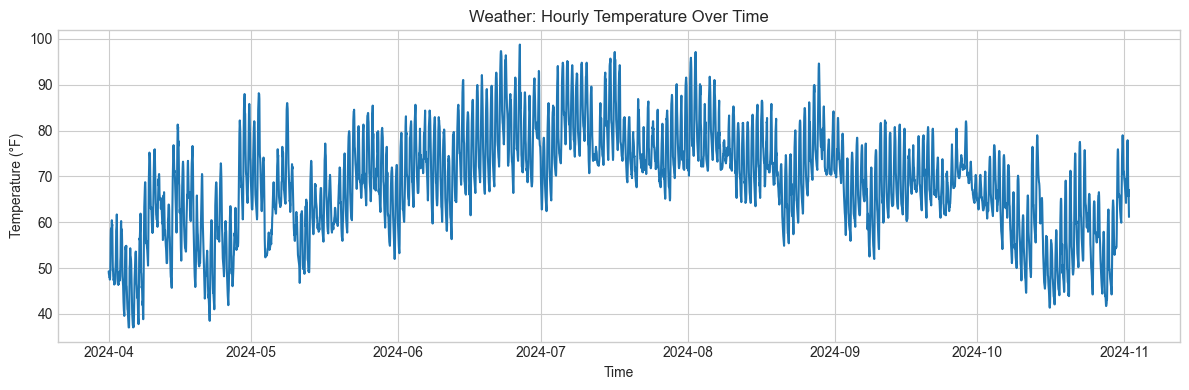

In [7]:
# Weather: hourly average temperature over time
weather_hourly = df_weather.set_index('Time').resample('1h').mean(numeric_only=True)
plt.figure(figsize=(12,4))
plt.plot(weather_hourly.index, weather_hourly['Temperature_F'])
plt.title('Weather: Hourly Temperature Over Time')
plt.xlabel('Time')
plt.ylabel('Temperature (°F)')
plt.tight_layout()
plt.show()

### 6.2 Histograms

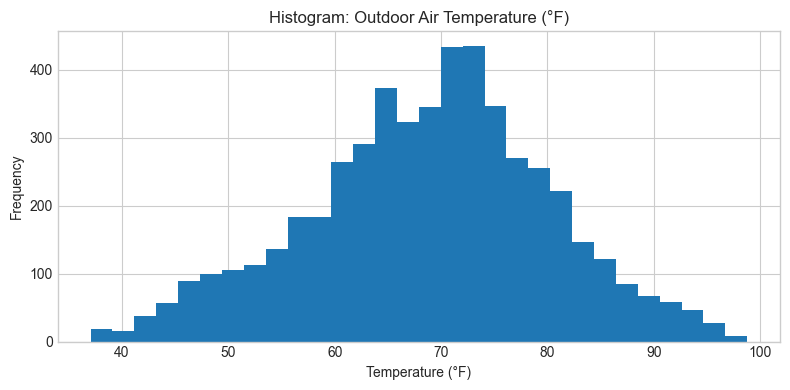

In [8]:
# Weather histogram
plt.figure(figsize=(8,4))
df_weather['Temperature_F'].hist(bins=30)
plt.title('Histogram: Outdoor Air Temperature (°F)')
plt.xlabel('Temperature (°F)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### 6.3 Average by Hour of Day & Weekday vs Weekend

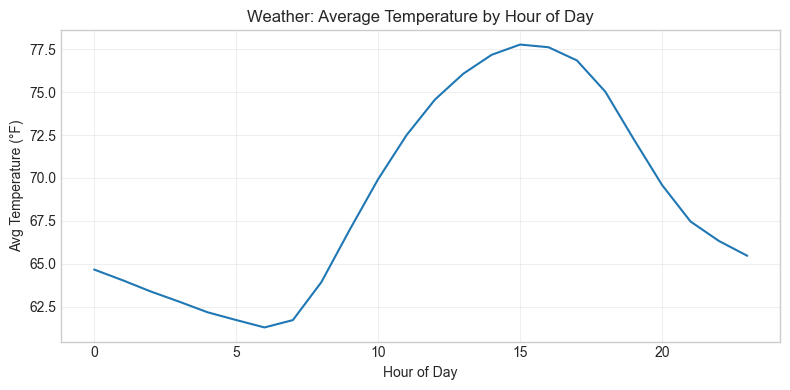

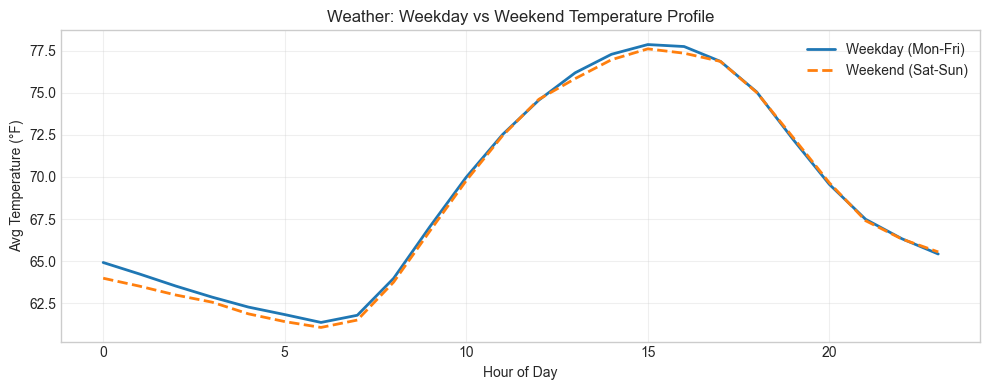

In [9]:
# Weather: average temperature by hour of day
weather_hour_mean = df_weather.groupby('hour')['Temperature_F'].mean()
plt.figure(figsize=(8,4))
weather_hour_mean.plot()
plt.title('Weather: Average Temperature by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Avg Temperature (°F)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Weather weekday vs weekend profile
weather_weekday = df_weather[~df_weather['is_weekend']]
weather_weekend = df_weather[df_weather['is_weekend']]
w_weekday_hour = weather_weekday.groupby('hour')['Temperature_F'].mean()
w_weekend_hour = weather_weekend.groupby('hour')['Temperature_F'].mean()
plt.figure(figsize=(10,4))
w_weekday_hour.plot(label='Weekday (Mon-Fri)', linewidth=2)
w_weekend_hour.plot(label='Weekend (Sat-Sun)', linewidth=2, linestyle='--')
plt.title('Weather: Weekday vs Weekend Temperature Profile')
plt.xlabel('Hour of Day')
plt.ylabel('Avg Temperature (°F)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.4 Heatmaps (Day of Week × Hour of Day)

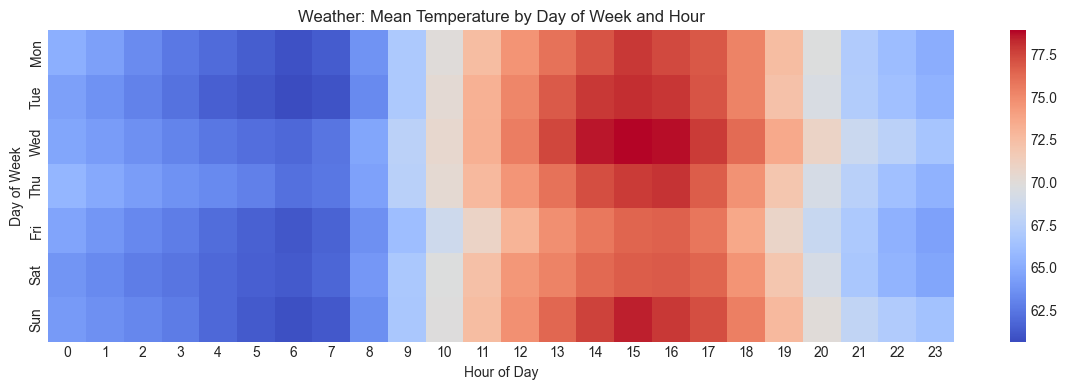

In [10]:
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Weather heatmap: mean temp by dow, hour_int
pivot_w = df_weather.groupby(['dow', 'hour_int'])['Temperature_F'].mean().unstack()
pivot_w.index = days
plt.figure(figsize=(12,4))
sns.heatmap(pivot_w, cmap='coolwarm', annot=False)
plt.title('Weather: Mean Temperature by Day of Week and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

## 7. Stationarity Tests (ADF + KPSS)

We now run formal **stationarity tests** on the three key series:

- Weather: `Temperature_F`
- Occupancy binary: `is_occupied_int`
- Occupancy lagged/smoothed: `clean_count`

**ADF (Augmented Dickey–Fuller)**
- H0: Series has a unit root (**non-stationary**)
- If p-value < 0.05 → reject H0 → stationary

**KPSS**
- H0: Series is **stationary** (around a constant)
- If p-value < 0.05 → reject H0 → non-stationary

In [11]:
def adf_test(series, signif=0.05, name='', verbose=True):
    """Augmented Dickey-Fuller test. H0: Series has a unit root (non-stationary)."""
    r = adfuller(series.dropna(), autolag='AIC')
    output = {
        'Test Statistic': r[0],
        'p-value': r[1],
        '# Lags Used': r[2],
        '# Observations Used': r[3],
    }
    if verbose:
        print(f"ADF Test on '{name}'")
        for k, v in output.items():
            print(f'   {k}: {v}')
        if r[1] <= signif:
            print(f'   => Reject H0 (p <= {signif}) → Stationary')
        else:
            print(f'   => Fail to Reject H0 (p > {signif}) → Non-stationary')
        print('')
    return output

def kpss_test(series, signif=0.05, name='', verbose=True):
    """KPSS test. H0: Series is stationary (around a constant)."""
    r = kpss(series.dropna(), regression='c', nlags='auto')
    output = {
        'Test Statistic': r[0],
        'p-value': r[1],
        '# Lags Used': r[2],
    }
    if verbose:
        print(f"KPSS Test on '{name}'")
        for k, v in output.items():
            print(f'   {k}: {v}')
        if r[1] <= signif:
            print(f'   => Reject H0 (p <= {signif}) → Non-stationary')
        else:
            print(f'   => Fail to Reject H0 (p > {signif}) → Stationary')
        print('')
    return output

print('=== Weather Temperature ===')
adf_test(df_weather['Temperature_F'], name='Temperature_F')
kpss_test(df_weather['Temperature_F'], name='Temperature_F')


=== Weather Temperature ===
ADF Test on 'Temperature_F'
   Test Statistic: -4.650640225677058
   p-value: 0.00010407942264331125
   # Lags Used: 25
   # Observations Used: 5134
   => Reject H0 (p <= 0.05) → Stationary

KPSS Test on 'Temperature_F'
   Test Statistic: 2.2150664245045886
   p-value: 0.01
   # Lags Used: 41
   => Reject H0 (p <= 0.05) → Non-stationary



C:\Users\ben\AppData\Local\Temp\ipykernel_12092\1055393754.py:23: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  r = kpss(series.dropna(), regression='c', nlags='auto')


{'Test Statistic': np.float64(2.2150664245045886),
 'p-value': np.float64(0.01),
 '# Lags Used': 41}

## 8. Wrap-Up

- **Weather** is typically **non-stationary**, so weekly baselines are crude; a season-aware weekly baseline helps a bit, but stationarity tests usually flag issues.
- **Binary occupancy** shows a highly repeatable weekly pattern; the weekly baseline matches it closely, which is reflected in low RMSE and more stable stationarity behavior.
- **`clean_count`** is a smoothed, lagged version of occupancy; it still follows a weekly pattern, so the same baseline idea works, but the distribution and stationarity are slightly different.

This notebook intentionally sticks to **baseline-style models plus robust plots and tests**, making it a clean reference for how far you can go *without* ML.